In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("data/kc_house_data.csv")

In [29]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [32]:
# Check Dataset Shape
df.shape

(21613, 21)

In [33]:
# 21613 : rows, 21 : columns

In [35]:
df.columns      # This helps understand available features

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [37]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [38]:
# Check Missing Values

df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [39]:
# Exploratory Data Analysis (EDA) where you'll visualize the data and understand relationships before building the Linear Regression model.

In [41]:
# Think of EDA as : 
#  "Understanding the dataset before teachinbg it to the machine."


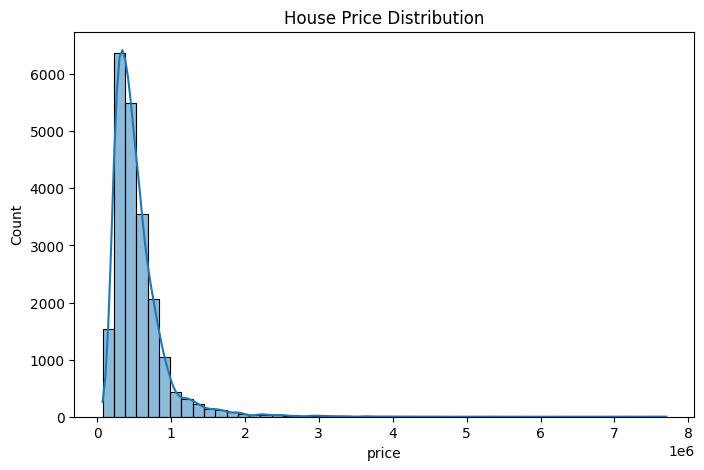

In [46]:
#  How house prices are distributed 

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("House Price Distribution")
plt.show()

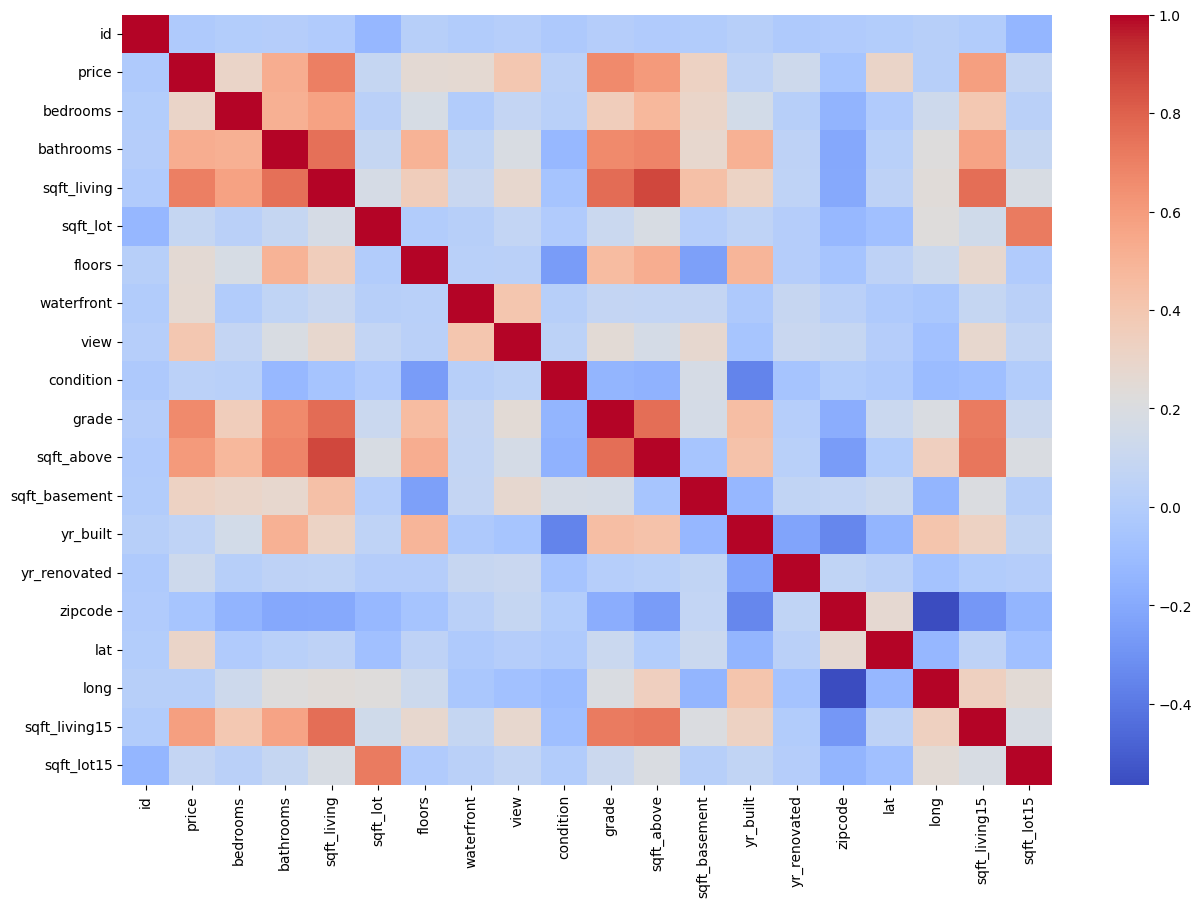

In [48]:
# Corrrlation Matrix : This Shows which features are most related to price.

corr_matrix  = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

In [49]:
# Featrues Most Correlated With Price

corr_matrix['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64

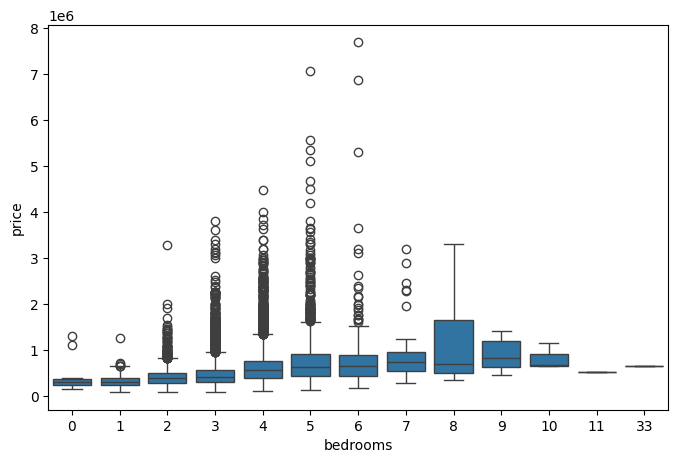

In [54]:
# Bedrooms Vs Price 
# sns is the alias for the Seaborn library.

plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.show()

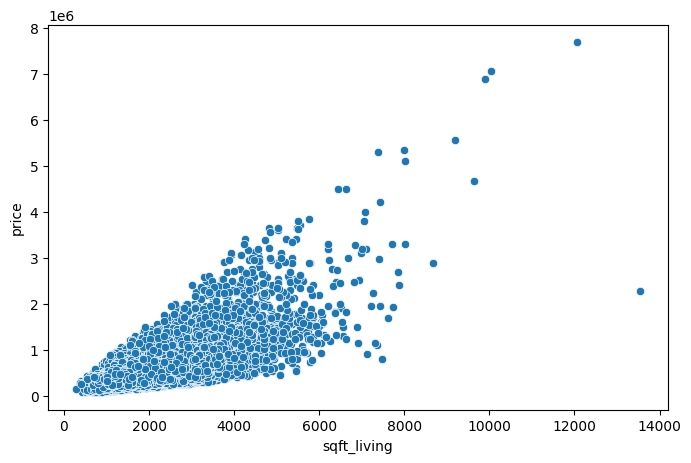

In [55]:
# Living Area vs Price 
plt.figure(figsize=(8,5))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.show()

In [56]:
# Usually : Larger house => Higher Price
# This is exactly what Linear Regression likes.

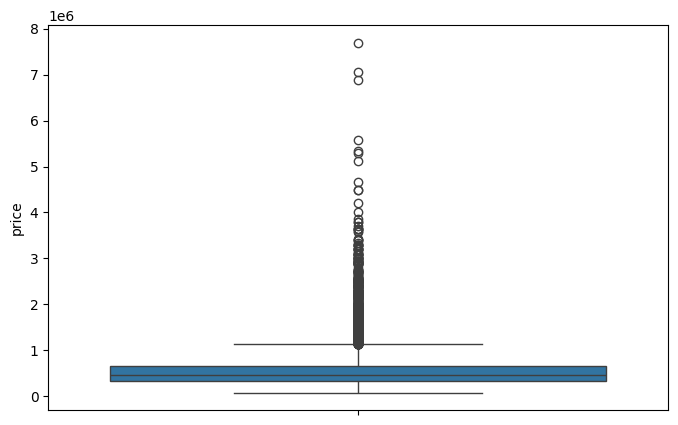

In [57]:
# Check Outliers
plt.figure(figsize=(8,5))
sns.boxplot(y=df['price'])
plt.show()

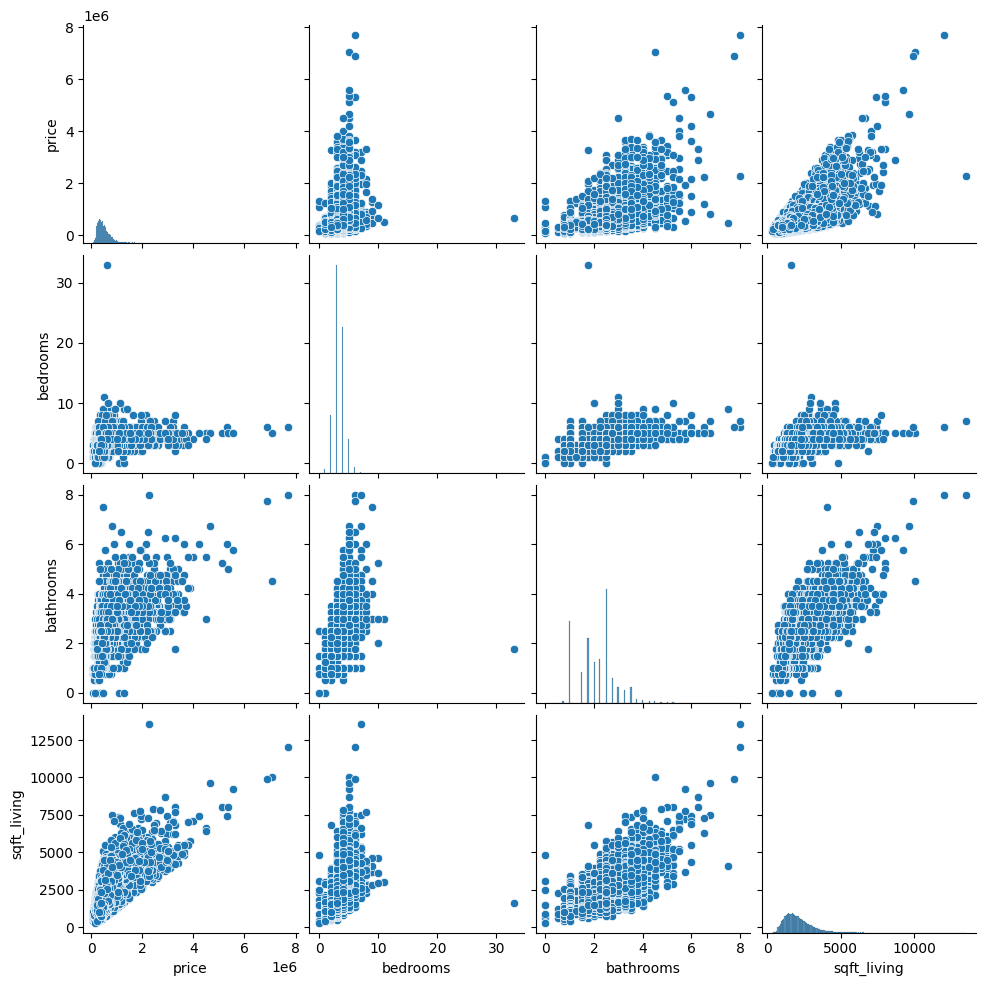

In [58]:
# Pair Plot 
features = ['price', 'bedrooms', 'bathrooms', 'sqft_living']

sns.pairplot(df[features])
plt.show()

In [59]:
# Data Preprocessing & Feature Selection 


In [60]:
# Check Missing Values Again 
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [61]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [63]:
# Remove Unnecessary Columns
# Some columns do not help in prediction 
df = df.drop(['id', 'date'], axis=1)

In [64]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [66]:
# Select Features (X) and Target (y)

y = df['price']

x = df.drop('price', axis=1)

In [67]:
print(x.shape)
print(y.shape)

(21613, 18)
(21613,)


In [69]:
 # Check Data Types 

x.dtypes

bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [73]:
# Feature Scaling (Important)

# => Linear Regression can work without scaling, but scaling is a good habit.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)   # Scale Features 

x_scaled   # Check


array([[-0.39873715, -1.44746357, -0.97983502, ..., -0.30607896,
        -0.9433552 , -0.26071541],
       [-0.39873715,  0.1756067 ,  0.53363434, ..., -0.74634143,
        -0.43268619, -0.18786773],
       [-1.47395936, -1.44746357, -1.42625404, ..., -0.13565477,
         1.07013975, -0.17237524],
       ...,
       [-1.47395936, -1.77207762, -1.15404732, ..., -0.60432128,
        -1.41025258, -0.39414129],
       [-0.39873715,  0.50022075, -0.52252773, ...,  1.02891048,
        -0.8412214 , -0.42051149],
       [-1.47395936, -1.77207762, -1.15404732, ..., -0.60432128,
        -1.41025258, -0.41794772]], shape=(21613, 18))

In [75]:
# Convert Backe to DataFrame 

X_scaled = pd.DataFrame(
    x_scaled,
    columns=x.columns
)

X_scaled.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.087173,-0.305759,-0.629187,-0.558836,-0.734708,-0.658681,-0.544898,-0.210128,1.870152,-0.352572,-0.306079,-0.943355,-0.260715
1,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.087173,-0.305759,-0.629187,-0.558836,0.460841,0.245141,-0.681079,4.746678,0.879568,1.161568,-0.746341,-0.432686,-0.187868
2,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.087173,-0.305759,-0.629187,-1.409587,-1.229834,-0.658681,-1.293892,-0.210128,-0.933388,1.283537,-0.135655,1.070140,-0.172375
3,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.087173,-0.305759,2.444294,-0.558836,-0.891699,1.397515,-0.204446,-0.210128,1.085160,-0.283288,-1.271816,-0.914174,-0.284522
4,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.087173,-0.305759,-0.629187,0.291916,-0.130895,-0.658681,0.544548,-0.210128,-0.073636,0.409550,1.199335,-0.272190,-0.192849


In [76]:
# Train-Test Split and Build Your First Linear Regression Model

# Split Data into Training and Testing Sets


# Why?

# Training Data → Used to learn patterns.
# Testing Data → Used to evaluate performance on unseen data.



In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size = 0.2,
    random_state=42
)

In [79]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17290, 18)
X_test: (4323, 18)
y_train: (17290,)
y_test: (4323,)


In [80]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

In [81]:
# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[-31933.32, 34321.16, 80795.07,...,-27402.55, 14539.78, -8896.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['bedrooms','bathrooms','sqft_living',...,'long','sqft_living15', 'sqft_lot15']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.395e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,17


In [82]:
# Make Predictions 
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 461209.94695867  752443.5100695  1238489.80205784 1662423.82332026
  734889.5957703 ]


In [84]:
# Compare Actual vs Predicted 
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,365000.0,4.612099e+05
1,865000.0,7.524435e+05
2,1038000.0,1.238490e+06
3,1490000.0,1.662424e+06
4,711000.0,7.348896e+05
5,211000.0,2.825582e+05
6,790000.0,8.319284e+05
7,680000.0,5.003700e+05
8,384500.0,3.843639e+05
9,605000.0,4.794183e+05


In [88]:
# Check Model Coefficients 

# This shows how each feature affects house price.

coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
8,grade,111158.084778
14,lat,82577.643754
2,sqft_living,80795.073362
9,sqft_above,75409.776432
5,waterfront,48657.277095
6,view,41105.171777
1,bathrooms,34321.164242
10,sqft_basement,26570.283072
7,condition,15960.216811
16,sqft_living15,14539.781347


In [90]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[-31933.32, 34321.16, 80795.07,...,-27402.55, 14539.78, -8896.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['bedrooms','bathrooms','sqft_living',...,'long','sqft_living15', 'sqft_lot15']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.395e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,17


In [91]:
# COmpleted :

# 1. Split data into train and test sets 
# 2. Create Linear Regression Model
# 3. Train the model 
# 4. Make Predictions
# 5. Compare actual vs predicted values 




In [92]:
#  Step 6: Model Evaluation and Visualization 📊


# Training a model is not enough.

# Now we need to answer:

# "How good is my model?"



In [93]:
# Import Evaluation Metrics 
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [95]:
# Calculate MAE

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)   # Average prediction error

MAE: 127493.34208656978


In [96]:
# Calculte MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 45173046132.79015


In [98]:
#  Calculate RMSE

# RMSE is the most commonly used regression metric.

# Lower RMSE = Better Model

rmse = np.sqrt(mse)
print("RMSE:", rmse) 

RMSE: 212539.51663817756


In [100]:
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print("r2 Score:", r2)

r2 Score: 0.7011904448878412


In [ ]:
# Understanding R²

# R² Score	Meaning
# 1.0	Perfect prediction
# 0.9	Excellent
# 0.8	Very Good
# 0.7	Good
# 0.6	Acceptable
# <0.5	Needs improvement

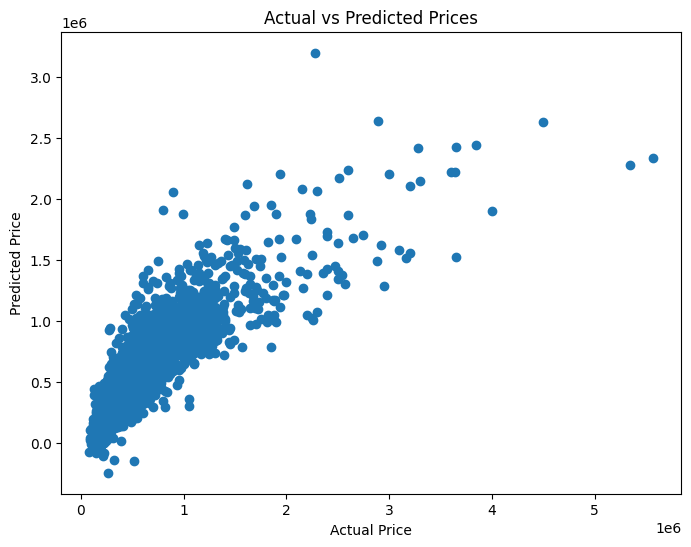

In [101]:
#  Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [110]:
# Residual Plot 
residuals  = y_test - y_pred 


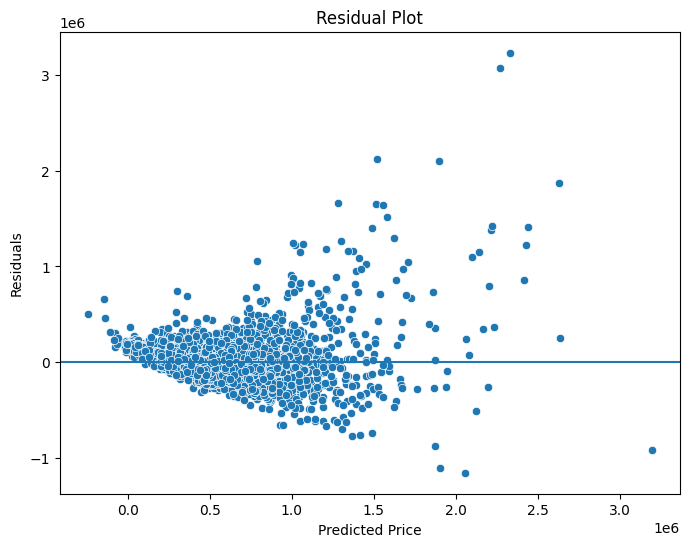

In [111]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [112]:
# Residual Plot 
# residuals = y_test - y_pred

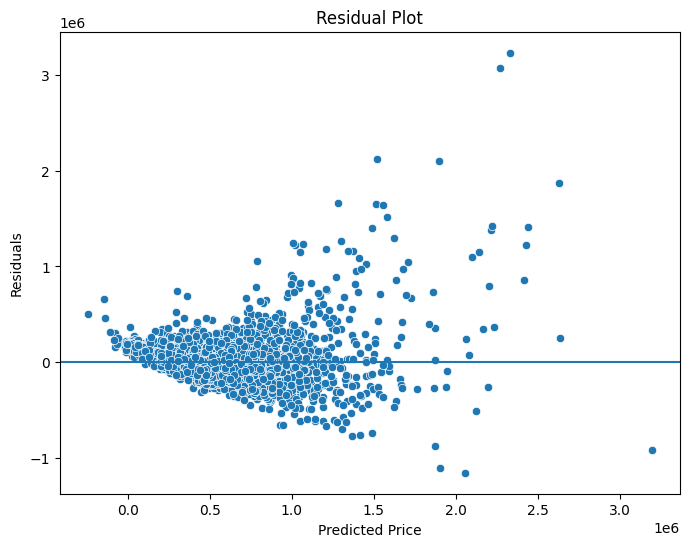

In [114]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x = y_pred,
    y = residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [115]:
print("Model Performance")
print("-"*30)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
------------------------------
MAE : 127493.34208656978
MSE : 45173046132.79015
RMSE: 212539.51663817756
R²  : 0.7011904448878412


In [118]:
# Save the Model and Predict Price for a New House 💾

# Save the Trained Model

import pickle

with open("models/house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("models/scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [119]:
# Verify Files
import os

os.listdir("models")

['house_price_model.pkl', 'scaler.pkl']

In [120]:
# Load Saved Model 

with open("models/house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("models/scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

In [122]:
# Create Sample Hourse Data
x.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [123]:
sample_house = [[
    3,      # bedrooms
    2,      # bathrooms
    1800,   # sqft_living
    5000,   # sqft_lot
    1,      # floors
    0,      # waterfront
    0,      # view
    3,      # condition
    7,      # grade
    1800,   # sqft_above
    0,      # basement
    2005,   # yr_built
    0,      # yr_renovated
    98001,  # zipcode
    47.5,   # lat
    -122.2, # long
    1700,   # sqft_living15
    4800    # sqft_lot15
]]


In [124]:
#  Scale New Data

sample_house_scaled = loaded_scaler.transform(sample_house)

C:\Users\sunny\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [125]:
# Predict Price 

sample_house_scaled = loaded_scaler.transform(sample_house)

C:\Users\sunny\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [126]:
# Create a Reusable Function 
def predict_house_price(features):
    features_scaled = loaded_scaler.transform([features])
    prediction = loaded_model.predict(features_scaled)
    return prediction[0]

In [128]:
# Save Feature Names (Good Practice)

feature_names = x.columns.tolist()

with open("models/features.pkl", "wb") as file:
    pickle.dump(feature_names, file)

In [ ]:
# What You Have Built 

User Inputs Data
       ↓
Streamlit App
       ↓
Scaler
       ↓
Linear Regression Model
       ↓
Predicted Price
       ↓
Displayed on Screen

In [ ]:
Resume Project Title

House Price Prediction using Linear Regression

Tech Stack
Python
Pandas
NumPy
Matplotlib
Seaborn
Scikit-Learn
Streamlit

In [133]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'data', 'House_Price_Prediction.ipynb', 'models', 'notebook', 'README.md', 'requirements.txt']
